In [1]:
import pandas as pd


train = pd.read_csv('drugsComTrain_raw.csv')
test = pd.read_csv('drugsComTest_raw.csv')
df = pd.concat([train, test], ignore_index=True)
print(df.shape)
df.head()

(215063, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [2]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
141037,69003,Medroxyprogesterone,Abnormal Uterine Bleeding,"""Horrible form of birth control. With all of t...",1,22-Mar-16,2
27552,126815,Dilaudid,Pain,"""This is the best pain reliever I have ever en...",10,17-Dec-10,20
95,45237,Fluoxetine,Major Depressive Disorde,"""I started Prozac as one of my first anti depr...",2,12-Jan-16,18
97364,4500,Belviq,Obesity,"""My BMI was 38 so I tried it. I hated the side...",1,27-Sep-16,10
165242,208544,Amlodipine / olmesartan,High Blood Pressure,"""This is my first week on Azor and not only is...",10,1-May-10,38
29978,15010,Ethinyl estradiol / norethindrone,Birth Control,"""I just started 2 months ago I&#039;m entering...",6,31-Jul-17,3
213002,40165,Amiodarone,Arrhythmia,"""On this medicine for 6 yrs. No recognized si...",10,1-Dec-11,91
122794,227965,Etonogestrel,Birth Control,"""I really loved my Implanon the first 8 months...",5,6-Jan-11,0
111918,44264,Ethinyl estradiol / norgestimate,NaN,"""I have been on Triness for about 7 months. I ...",8,5-Apr-11,2
204333,13354,Amphetamine / dextroamphetamine,ADHD,"""I began taking adderrall XR generic and it ha...",10,17-Feb-16,7


In [3]:
df.describe()

,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [4]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 11.5+ MB


In [5]:
# Check exact counts of missing data
print(df.isna().sum())

# Drop rows where the 'condition' is missing
df = df.dropna(subset=['condition'])

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64


In [6]:
# Convert date string to datetime using the exact format
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%y')

In [7]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
58878,229964,Lurasidone,Bipolar Disorde,"""I&#039;m hoping my comments reaches out to th...",10,2017-03-14,62
7576,200416,Varenicline,Smoking Cessation,"""It is a miracle pill! After saying that, you ...",10,2013-10-31,30
185522,25253,Tofacitinib,Rheumatoid Arthritis,"""moderate/severe RA, it&#039;s not recommended...",1,2017-03-26,25
166405,53518,Sharobel,Birth Control,"""I&#039;ve had extreme hair loss. To the point...",1,2016-12-04,10
28996,28384,Lexapro,Depression,"""As a mother of two young boys I started feeli...",10,2014-04-25,122
187534,42524,Concerta,ADHD,"""I&#039;ve been taking Concerta for nearly fiv...",6,2015-08-28,23
16439,225445,Bupropion,Major Depressive Disorde,"""I have more energy and want to clean things u...",10,2015-03-02,24
113849,201774,Alprazolam,Anxiety,"""This drug saved my life. I have suffered from...",9,2008-06-07,6
61237,160864,Buspirone,Anxiety,"""I have been taking Buspirone for 6 months. Be...",9,2008-12-19,21
134458,177843,Duloxetine,Depression,"""I absolutely love this medicine so far the on...",8,2013-05-06,81


In [8]:
# Optionally done
df['year'] = df['date'].dt.year

In [9]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount,year
53884,159520,Gabapentin enacarbil,Restless Legs Syndrome,"""This medication actually works. I used to tak...",10,2012-09-23,54,2012
95106,201184,Zoloft,Depression,"""This medication worked wonderful for me. Tota...",8,2016-11-02,36,2016
134850,197333,Paroxetine,Anxiety and Stress,"""Paroxetine does it&#039;s job. Tried others b...",10,2012-03-13,12,2012
140440,127148,Metoclopramide,Nausea/Vomiting,"""I was given the medication in tablet form whe...",1,2016-04-20,8,2016
139177,25871,Ethinyl estradiol / norelgestromin,Birth Control,"""I love this birth control! I&#039;ve been on ...",9,2012-01-16,2,2012
208904,97420,St. john's wort,Depression,"""I am a 27 y/o female, have been battling depr...",3,2017-02-13,17,2017
70747,227365,Etonogestrel,Birth Control,"""I&#039;ve had Nexplanon in for two weeks and ...",9,2013-09-04,7,2013
56392,107795,Implanon,Birth Control,"""I had Implanon inserted on the 28/08 this yea...",8,2009-10-22,0,2009
57047,127384,Disulfiram,Alcohol Dependence,"""I initially started on Antabuse when I realiz...",9,2017-01-06,23,2017
119532,18718,Depo-Medrol,Osteoarthritis,"""I get an injection (40) in my hip and knee ev...",10,2013-07-17,35,2013


<Axes: xlabel='rating', ylabel='count'>

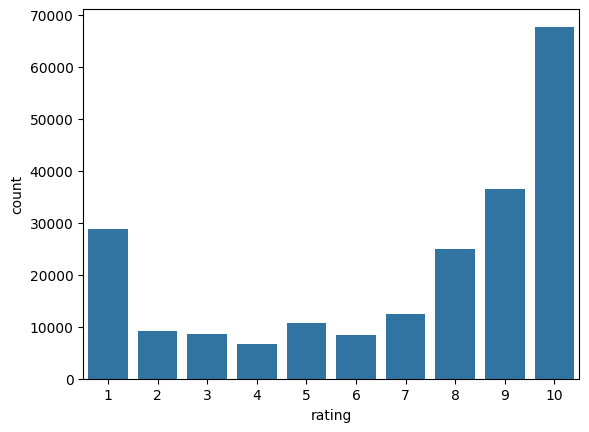

In [10]:
import seaborn as sns

sns.countplot(x='rating', data=df)

(0.0, 400.0)

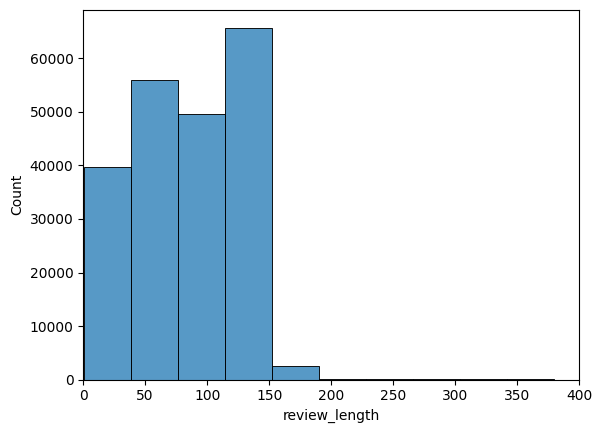

In [11]:
import matplotlib.pyplot as plt

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))
sns.histplot(df['review_length'], bins=50)
plt.xlim(0,400)

In [12]:
with pd.option_context('display.max_rows', None):
    print(df['condition'].value_counts())

condition
Birth Control                                                          38436
Depression                                                             12164
Pain                                                                    8245
Anxiety                                                                 7812
Acne                                                                    7435
Bipolar Disorde                                                         5604
Insomnia                                                                4904
Weight Loss                                                             4857
Obesity                                                                 4757
ADHD                                                                    4509
Diabetes, Type 2                                                        3362
Emergency Contraception                                                 3290
High Blood Pressure                                               

In [13]:
with pd.option_context('display.max_rows', None):
    print(df['drugName'].value_counts())

drugName
Levonorgestrel                                                                                      4896
Etonogestrel                                                                                        4402
Ethinyl estradiol / norethindrone                                                                   3619
Nexplanon                                                                                           2892
Ethinyl estradiol / norgestimate                                                                    2682
Ethinyl estradiol / levonorgestrel                                                                  2400
Phentermine                                                                                         2077
Sertraline                                                                                          1859
Escitalopram                                                                                        1739
Mirena                                        

In [14]:
# Checking how many duplicate uniqueIDs exist
dup_count = df['uniqueID'].duplicated().sum()
print(f"Number of duplicate IDs: {dup_count}")

Number of duplicate IDs: 0


In [15]:
from collections import Counter

# Initialize a Counter object
word_freq = Counter()

# Iterate through the reviews, lowercase them, split into words, and update the counter
for text in df['review'].dropna().astype(str):
    word_freq.update(text.lower().split())

# Print the top 20 most common words
print("Top 20 raw words before cleaning:")
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}")

Top 20 raw words before cleaning:
i: 889097
and: 568647
the: 534815
to: 425427
a: 380447
my: 378317
it: 320398
for: 264884
was: 230901
of: 226216
have: 225288
on: 176168
in: 162326
but: 159648
this: 158356
had: 149264
is: 147514
with: 136547
that: 129752
me: 119425


In [16]:
# Defining a function to map the numeric rating to a text label
def categorize_sentiment(rating):
    if rating >= 7:
        return 'Positive'
    elif rating <= 4:
        return 'Negative'
    else:
        return None

df['sentiment'] = df['rating'].apply(categorize_sentiment)

# Check the distribution of our new labels to see if the classes are balanced
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

Sentiment Distribution:
sentiment
Positive    141560
Negative     53256
Name: count, dtype: int64


In [33]:
df.isna().sum()

uniqueID             0
drugName             0
condition            0
review               0
rating               0
date                 0
usefulCount          0
year                 0
review_length        0
sentiment        19053
clean_review         0
dtype: int64

In [34]:
df = df.dropna(subset=['sentiment'])

In [35]:
import re
html_present = df['review'].str.contains(r'<.*?>', regex=True).sum()
print(f"Reviews with HTML tags: {html_present}")

Reviews with HTML tags: 0


In [36]:
entity_present = df['review'].str.contains(r'&#\d+;', regex=True).sum()
print(f"Reviews with HTML entities: {entity_present}")

Reviews with HTML entities: 120774


In [37]:
# Find one review that has HTML entities and print it raw
sample_dirty = df[df['review'].str.contains(r'&#\d+;', regex=True)]['review'].iloc[0]
print(sample_dirty)

"This is my first time using any form of birth control. I&#039;m glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is that it made my periods longer (5-6 days to be exact) I used to only have periods for 3-4 days max also made my cramps intense for the first two days of my period, I never had cramps before using birth control. Other than that in happy with the patch"


In [38]:
import html

sample_clean = html.unescape(sample_dirty)
print(sample_clean)

"This is my first time using any form of birth control. I'm glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is that it made my periods longer (5-6 days to be exact) I used to only have periods for 3-4 days max also made my cramps intense for the first two days of my period, I never had cramps before using birth control. Other than that in happy with the patch"


In [39]:
url_present = df['review'].str.contains(r'http\S+|www\.\S+', regex=True).sum()
print(f"Reviews with URLs: {url_present}")

Reviews with URLs: 29


In [40]:
sample_url = df[df['review'].str.contains(r'http\S+|www\.\S+', regex=True)]['review'].iloc[0]
print(sample_url)

"I have trouble sleeping from 3 - 6 am.  I wake up and cannot go back to sleep creating the daytime symptoms of insomnia (see: http://www.mayoclinic.org/diseases-conditions/insomnia/basics/definition/CON-20024293 ). I rarely have trouble falling asleep.
I have been taking LIQUID doxepin for 18+ months (along with a 5 mg time release melatonin) - 30 min before bedtime.  The LIQUID has to be especially prescribed by your Dr and approved by your drug company.  A 120 ml bottle is $79 - with medicare &amp; drug co approval, my out of pocket (last bought in 6/2016) was $7! Much cheaper than Silenor.  I am prescribed 0.6ml/night, but sometimes I take 0.5ml or less, &amp; never over 0.7ml (rarely).
Doxepin &amp; melatonin work well to help me sleep from 10p-6a!"


In [41]:
import re
import html

def clean_text(text):
    text = str(text)                              # ensure string type
    text = html.unescape(text)                    # fix &#039; &amp; etc
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove URLs
    text = text.lower()                           # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()      # clean extra whitespace
    return text

print(clean_text(sample_url))

i have trouble sleeping from am i wake up and cannot go back to sleep creating the daytime symptoms of insomnia see i rarely have trouble falling asleep i have been taking liquid doxepin for months along with a mg time release melatonin min before bedtime the liquid has to be especially prescribed by your dr and approved by your drug company a ml bottle is with medicare drug co approval my out of pocket last bought in was much cheaper than silenor i am prescribed ml night but sometimes i take ml or less never over ml rarely doxepin melatonin work well to help me sleep from p a


In [42]:
df['clean_review'] = df['review'].apply(clean_text)

In [43]:
for i in df.sample(3).index:
    print("BEFORE:", df['review'][i][:150])
    print("AFTER: ", df['clean_review'][i][:150])
    print()

BEFORE: "My shrink upped my doses to 200 mg and I think that&#039;s to much because I started to get a rapid heart beat. I lost about 20 pounds due to my majo
AFTER:  my shrink upped my doses to mg and i think that s to much because i started to get a rapid heart beat i lost about pounds due to my major depression i

BEFORE: "Caused hair loss, moods were crazy- very anxious and memory loss.  After 8 weeks the weight loss is not worth it. 5lbs and I bet that was just in hai
AFTER:  caused hair loss moods were crazy very anxious and memory loss after weeks the weight loss is not worth it lbs and i bet that was just in hair loss

BEFORE: "I felt better during the day after about a week, but the side effects have been unpleasant. Mainly the lack of sleep. Since the first day I started I
AFTER:  i felt better during the day after about a week but the side effects have been unpleasant mainly the lack of sleep since the first day i started i cou



In [44]:
df['clean_review'].isna().sum()

np.int64(0)

In [45]:
import nltk
from nltk.corpus import stopwords

def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['clean_review'] = df['clean_review'].apply(remove_stopwords)
print(df['clean_review'].iloc[0][:300])

side effect take combination bystolic mg fish oil


In [46]:
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords

# stop_words = set(stopwords.words('english'))

# df['clean_review'] = df['clean_review'].apply(
#     lambda x: ' '.join([w for w in x.split() if w not in stop_words])
# )


# other way of doing above step

In [47]:
df.isna().sum()

uniqueID         0
drugName         0
condition        0
review           0
rating           0
date             0
usefulCount      0
year             0
review_length    0
sentiment        0
clean_review     0
dtype: int64

In [50]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,year,review_length,sentiment,clean_review
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,2012,17,Positive,side effect take combination bystolic mg fish oil
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,2010,141,Positive,son halfway fourth week intuniv became concern...
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,2015,89,Positive,first time using form birth control glad went ...
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,2016,124,Positive,suboxone completely turned life around feel he...
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,2015-11-28,43,2015,68,Negative,nd day mg started work rock hard erections how...
...,...,...,...,...,...,...,...,...,...,...,...
215058,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,2014-09-13,43,2014,97,Positive,taken tamoxifen years side effects severe swea...
215059,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,2016-10-08,11,2016,130,Positive,taking lexapro escitaploprgram since february ...
215060,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,2010-11-15,7,2010,149,Positive,married years old kids taking pill hassle deci...
215061,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,2011-11-28,20,2011,34,Negative,prescribed nucynta severe neck shoulder pain t...


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentiment']
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 155852
Test size: 38964


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

Train shape: (155852, 5000)
Test shape: (38964, 5000)


In [52]:
"""The max_features parameter acts as a strict cap on the vocabulary size your model will build. Instead of 
creating a column for every single unique word found across all 155,000+ reviews, 
it tells scikit-learn to only keep the top 5,000 most frequent words in your training data."""

'The max_features parameter acts as a strict cap on the vocabulary size your model will build. Instead of \ncreating a column for every single unique word found across all 155,000+ reviews, \nit tells scikit-learn to only keep the top 5,000 most frequent words in your training data.'

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:,1]), 3))

              precision    recall  f1-score   support

    Negative       0.67      0.84      0.74     10651
    Positive       0.93      0.84      0.89     28313

    accuracy                           0.84     38964
   macro avg       0.80      0.84      0.81     38964
weighted avg       0.86      0.84      0.85     38964

ROC-AUC: 0.919


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

models = {
    # 'Random Forest': RandomForestClassifier(
    #     n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=53256/141560, random_state=42, eval_metric='logloss')
}

# Convert text labels to 0 and 1 for XGBoost
y_train_num = y_train.map({'Negative': 0, 'Positive': 1})
y_test_num = y_test.map({'Negative': 0, 'Positive': 1})

for name, model in models.items():
    # Make sure to use the new numeric variables here!
    model.fit(X_train_tfidf, y_train_num)
    y_pred = model.predict(X_test_tfidf)
    roc = roc_auc_score(y_test_num, model.predict_proba(X_test_tfidf)[:, 1])
    
    print(f"\n{name}")
    print(classification_report(y_test_num, y_pred))
    print(f"ROC-AUC: {round(roc, 3)}")


XGBoost
              precision    recall  f1-score   support

           0       0.64      0.84      0.72     10651
           1       0.93      0.82      0.87     28313

    accuracy                           0.83     38964
   macro avg       0.78      0.83      0.80     38964
weighted avg       0.85      0.83      0.83     38964

ROC-AUC: 0.909


In [ ]:
"""Note: scale_pos_weight in XGBoost is the equivalent of class_weight='balanced'
— it's the ratio of negative to positive samples, handles imbalance the XGBoost way."""

In [60]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_positive = [(feature_names[i], round(coefs[i], 3)) 
                for i in np.argsort(coefs)[-15:]]
top_negative = [(feature_names[i], round(coefs[i], 3)) 
                for i in np.argsort(coefs)[:15]]

print("Top Positive Words:")
for word, score in reversed(top_positive):
    print(f"  {word}: {score}")

print("\nTop Negative Words:")
for word, score in top_negative:
    print(f"  {word}: {score}")
    

Top Positive Words:
  love: 11.867
  miracle: 9.977
  saved: 9.732
  amazing: 9.223
  best: 8.179
  excellent: 7.222
  saver: 7.159
  wonderful: 6.561
  great: 6.419
  grateful: 6.407
  thankful: 6.368
  wonders: 5.96
  lifesaver: 5.929
  overall: 5.78
  condom: 5.742

Top Negative Words:
  disappointed: -7.417
  worse: -7.356
  worst: -6.799
  removed: -5.339
  ruined: -5.328
  gained: -5.236
  waste: -5.211
  useless: -5.022
  horrible: -4.81
  depressed: -4.685
  hopes: -4.643
  nightmare: -4.252
  calling: -4.208
  garbage: -4.097
  ineffective: -4.033


## Summary & Conclusions

- **Dataset:** 215k patient drug reviews from Drugs.com
- **Task:** Binary sentiment classification (Positive ≥7, Negative ≤4)
- **Text Pipeline:** HTML entity decoding → URL removal → 
  lowercasing → punctuation removal → stopword removal → TF-IDF (5000 features)
- **Best Model:** Logistic Regression — ROC-AUC: 0.919, Accuracy: 84%
- **Key Finding:** LR outperforms XGBoost on sparse TF-IDF features
- **Top Sentiment Drivers:** 'love', 'miracle', 'saved' (positive) 
  vs 'disappointed', 'ruined', 'nightmare' (negative)
- **Next Steps:** Try Word2Vec/BERT embeddings, 
  condition-specific sentiment analysis
  

In [62]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),

}

for name, model in models.items():
    # Make sure to use the new numeric variables here!
    model.fit(X_train_tfidf, y_train_num)
    y_pred = model.predict(X_test_tfidf)
    roc = roc_auc_score(y_test_num, model.predict_proba(X_test_tfidf)[:, 1])
    
    print(f"\n{name}")
    print(classification_report(y_test_num, y_pred))
    print(f"ROC-AUC: {round(roc, 3)}")


Random Forest
              precision    recall  f1-score   support

           0       0.96      0.81      0.88     10651
           1       0.93      0.99      0.96     28313

    accuracy                           0.94     38964
   macro avg       0.94      0.90      0.92     38964
weighted avg       0.94      0.94      0.94     38964

ROC-AUC: 0.981
